<a href="https://colab.research.google.com/github/indexkboss/CNN_et_Vision_Par_Ordinateur/blob/main/Partie_2_CNN_et_Vision_par_Ordinateur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Partie II : CNN et Vision par Ordinateur

1. Introduction
2. Présentation du Dataset
3. Exploration du Dataset
4. Pourquoi un MLP est peu adapté aux images
5. Théorie des CNN
6. Calculs manuels
7. Implémentations manuelles
8. Comparaison avec PyTorch
9. CNN LeNet
10. Études expérimentales
11. Visualisation des cartes de caractéristiques
12. Comparaison MLP vs CNN
13. Analyse critique
14. Question de synthèse

# Introduction : CNN et Vision par Ordinateur

L'objectif de cette partie est d'étudier les réseaux de neurones convolutionnels (CNN)
pour la classification d'images.

Contrairement aux données tabulaires utilisées dans la Partie I (MLP), les images possèdent
une structure spatiale que les CNN sont capables d'exploiter grâce aux opérations de
convolution et de pooling.

Le dataset choisi est MNIST, l'un des jeux de données les plus utilisés pour
l'apprentissage et l'évaluation des modèles de vision par ordinateur.

In [81]:
#Chargement Dataset:
import torch
import torchvision
import torchvision.transforms as transforms

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [82]:
#exploration des données:

In [83]:
print("Train :", len(train_dataset))
print("Test :", len(test_dataset))
print("Total :", len(train_dataset)+len(test_dataset))


Train : 60000
Test : 10000
Total : 70000


Le dataset MNIST contient 70 000 images de chiffres manuscrits.

Les données sont réparties en :

- 60 000 images d'entraînement ;
- 10 000 images de test.

Cette taille est suffisante pour entraîner efficacement un CNN tout en
restant compatible avec des ressources matérielles limitées.

In [84]:
image,label = train_dataset[0]

print(image.shape)

torch.Size([1, 28, 28])


Chaque image possède une taille de 28×28 pixels.

La première dimension correspond au nombre de canaux.

Comme MNIST est un dataset en niveaux de gris, chaque image possède un seul canal.

Les images couleur possèdent 3 canaux (RGB).

In [85]:
print(train_dataset.classes)

['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


Le dataset comporte dix classes correspondant aux chiffres manuscrits de 0 à 9.

Le problème étudié est donc un problème de classification multiclasse.

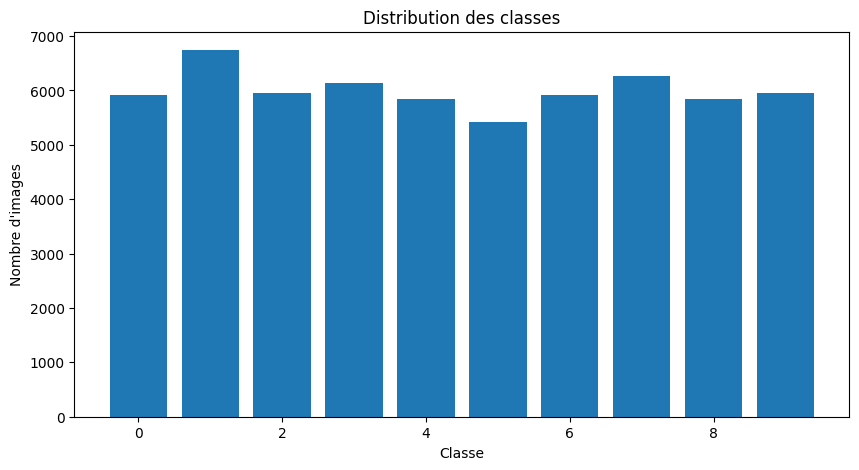

In [86]:
import matplotlib.pyplot as plt
from collections import Counter

labels = train_dataset.targets.numpy()

counts = Counter(labels)

plt.figure(figsize=(10,5))

plt.bar(
    counts.keys(),
    counts.values()
)

plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.title("Distribution des classes")

plt.show()

## Analyse

La distribution des classes apparaît relativement équilibrée.

Chaque chiffre est représenté par plusieurs milliers d'exemples.

Cet équilibre limite le risque qu'une classe soit favorisée durant l'apprentissage
et contribue à une meilleure généralisation du modèle.

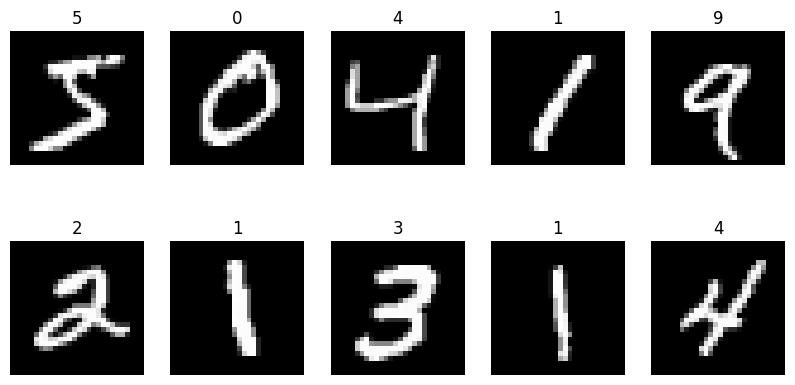

In [87]:
plt.figure(figsize=(10,5))

for i in range(10):

    image,label = train_dataset[i]

    plt.subplot(2,5,i+1)

    plt.imshow(
        image.squeeze(),
        cmap='gray'
    )

    plt.title(label)

    plt.axis('off')

plt.show()

In [88]:
image,_ = train_dataset[0]

print(image.min())
print(image.max())

tensor(0.)
tensor(1.)


Les pixels sont compris entre 0 et 1 grâce à la transformation ToTensor().

La valeur 0 représente un pixel noir tandis que la valeur 1 représente un pixel blanc.

Cette normalisation facilite l'entraînement des réseaux de neurones.

In [89]:
loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=60000
)

images,_ = next(iter(loader))

print(images.mean())
print(images.std())

tensor(0.1307)
tensor(0.3081)


La moyenne des pixels est d'environ 0.1307 et l'écart-type est d'environ 0.3081.

Ces statistiques seront utilisées pour normaliser les images avant
l'entraînement du CNN.

La normalisation permet de stabiliser la descente de gradient et
d'accélérer la convergence.

# Conclusion de l'exploration

L'analyse exploratoire du dataset MNIST montre qu'il s'agit d'un problème
de classification multiclasse comportant 70 000 images en niveaux de gris.

Les classes sont relativement équilibrées et les images présentent une forte
variabilité d'écriture.

La structure spatiale des pixels joue un rôle essentiel dans la reconnaissance
des chiffres. Cette caractéristique constitue une motivation importante pour
l'utilisation des réseaux de neurones convolutionnels, capables d'exploiter
les relations locales entre pixels.

**POUR LE RAPPORT: Chargement du Dataset MNIST**

MNIST est une base de données d'images de chiffres manuscrits.

Caractéristiques :

- 70 000 images
- 60 000 images d'entraînement
- 10 000 images de test
- 10 classes (0 à 9)
- Images en niveaux de gris
- Taille : 28 × 28 pixels

Objectif :
Classifier chaque image dans la bonne catégorie.


# Pourquoi un MLP est-il peu adapté aux images ?

Un MLP transforme une image 28×28 en un vecteur de 784 valeurs.

Cette transformation détruit la structure spatiale de l'image.

Deux pixels voisins deviennent simplement deux valeurs parmi 784.

Le MLP ne tient pas compte :

- des relations locales ;
- des motifs visuels ;
- de l'organisation spatiale.

Les CNN répondent à ce problème grâce :

- à la localité des récepteurs ;
- au partage des poids ;
- à l'extraction hiérarchique des caractéristiques.

Les premières couches apprennent les contours,
les couches intermédiaires apprennent les formes,
les couches profondes apprennent les objets complets.

In [90]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device utilisé :", device)

Device utilisé : cpu


In [91]:
# TRANSFORMATION DES IMAGES

transform = transforms.Compose([

    # Conversion image → Tensor
    transforms.ToTensor(),

    # Normalisation
    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])


# TÉLÉCHARGEMENT DU DATASET


train_dataset = torchvision.datasets.MNIST(

    root="./data",

    train=True,

    transform=transform,

    download=True
)

test_dataset = torchvision.datasets.MNIST(

    root="./data",

    train=False,

    transform=transform,

    download=True
)

In [92]:
# DATALOADER

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [93]:
print(len(train_dataset))

60000


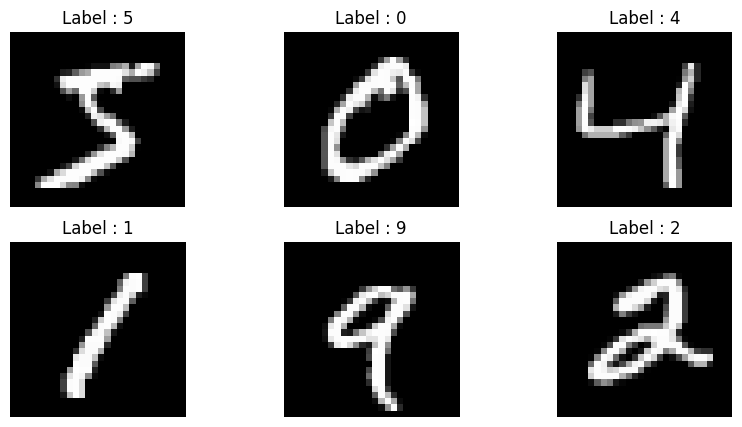

In [94]:
# VISUALISATION DES IMAGES

images, labels = next(iter(DataLoader(train_dataset,batch_size=6)))#train_loader

plt.figure(figsize=(10,5))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(
        images[i].squeeze(),
        cmap='gray'
    )

    plt.title(
        f"Label : {labels[i]}"
    )

    plt.axis('off')

plt.show()

# Calcul manuel de la taille de sortie

Formule :

Output = ((W - F + 2P)/S)+1

avec :

W = taille d'entrée
F = filtre
P = padding
S = stride

Exemple :

Entrée : 28×28

Filtre : 5×5

Padding : 0

Stride : 1

Output :

((28-5+0)/1)+1

=24

Sortie : 24×24

Après MaxPool 2×2 :

((24-2)/2)+1

=12

Sortie : 12×12

In [95]:
# CORRÉLATION CROISÉE Manuelle

def corr2d(X, K):

    h, w = K.shape

    Y = torch.zeros(
        (X.shape[0]-h+1,
         X.shape[1]-w+1)
    )

    for i in range(Y.shape[0]):

        for j in range(Y.shape[1]):

            Y[i,j] = (
                X[i:i+h,j:j+w] * K
            ).sum()

    return Y

In [96]:
#test:
X = torch.tensor([
    [0.,1.,2.],
    [3.,4.,5.],
    [6.,7.,8.]
])

K = torch.tensor([
    [0.,1.],
    [2.,3.]
])

print(corr2d(X,K))

tensor([[19., 25.],
        [37., 43.]])


In [97]:
# MAX POOLING MANUEL

def max_pool2d(X,size):

    h,w = size

    Y = torch.zeros(
        (
            X.shape[0]//h,
            X.shape[1]//w
        )
    )

    for i in range(Y.shape[0]):

        for j in range(Y.shape[1]):

            Y[i,j] = torch.max(

                X[
                    i*h:(i+1)*h,
                    j*w:(j+1)*w
                ]
            )

    return Y

In [98]:
# AVERAGE POOLING MANUEL

def avg_pool2d(X,size):

    h,w = size

    Y = torch.zeros(
        (
            X.shape[0]//h,
            X.shape[1]//w
        )
    )

    for i in range(Y.shape[0]):

        for j in range(Y.shape[1]):

            Y[i,j] = torch.mean(

                X[
                    i*h:(i+1)*h,
                    j*w:(j+1)*w
                ]
            )

    return Y

In [99]:
# #Comparaison avec PyTorch
# sample = torch.randn(1,1,28,28)

# max_pool = nn.MaxPool2d(2)

# avg_pool = nn.AvgPool2d(2)

# print(max_pool(sample).shape)

# print(avg_pool(sample).shape)


sample = torch.tensor([
    [1.,2.,3.,4.],
    [5.,6.,7.,8.],
    [9.,10.,11.,12.],
    [13.,14.,15.,16.]
])

manual_max = max_pool2d(
    sample,
    (2,2)
)

torch_max = nn.MaxPool2d(2)(
    sample.unsqueeze(0).unsqueeze(0)
)

print(manual_max)
print(torch_max.squeeze())

tensor([[ 6.,  8.],
        [14., 16.]])
tensor([[ 6.,  8.],
        [14., 16.]])


In [100]:
# # CNN TYPE LENET

# class CNN(nn.Module):

#     def __init__(self):

#         super().__init__()

#         self.conv1 = nn.Conv2d(
#             in_channels=1,
#             out_channels=6,
#             kernel_size=5
#         )

#         self.pool = nn.MaxPool2d(
#             kernel_size=2,
#             stride=2
#         )

#         self.conv2 = nn.Conv2d(
#             in_channels=6,
#             out_channels=16,
#             kernel_size=5
#         )

#         self.fc1 = nn.Linear(
#             16*4*4,
#             120
#         )

#         self.fc2 = nn.Linear(
#             120,
#             84
#         )

#         self.fc3 = nn.Linear(
#             84,
#             10
#         )

#     def forward(self,x):

#         x = self.pool(
#             torch.relu(
#                 self.conv1(x)
#             )
#         )

#         x = self.pool(
#             torch.relu(
#                 self.conv2(x)
#             )
#         )

#         x = torch.flatten(
#             x,
#             start_dim=1
#         )

#         x = torch.relu(
#             self.fc1(x)
#         )

#         x = torch.relu(
#             self.fc2(x)
#         )

#         x = self.fc3(x)

#         return x

class LeNet(nn.Module):

    def __init__(self,
                 padding=0,
                 stride=1,
                 pool_type="max",
                 filters=6,
                 use_conv1x1=False):

        super().__init__()

        self.use_conv1x1 = use_conv1x1

        self.conv1 = nn.Conv2d(
            1,
            filters,
            kernel_size=5,
            padding=padding,
            stride=stride
        )

        if pool_type=="max":
            self.pool = nn.MaxPool2d(2)
        else:
            self.pool = nn.AvgPool2d(2)

        self.conv2 = nn.Conv2d(
            filters,
            filters*2,
            kernel_size=5
        )

        if use_conv1x1:

            self.conv1x1 = nn.Conv2d(
                filters*2,
                filters*2,
                kernel_size=1
            )

        self.feature_size = self._get_feature_size()

        self.fc1 = nn.Linear(
            self.feature_size,
            120
        )

        self.fc2 = nn.Linear(
            120,
            84
        )

        self.fc3 = nn.Linear(
            84,
            10
        )

    def _get_feature_size(self):

        x = torch.zeros(
            1,1,28,28
        )

        x = self.pool(
            torch.relu(
                self.conv1(x)
            )
        )

        x = self.pool(
            torch.relu(
                self.conv2(x)
            )
        )

        if self.use_conv1x1:
            x = self.conv1x1(x)

        return x.numel()

    def forward(self,x):

        x = self.pool(
            torch.relu(
                self.conv1(x)
            )
        )

        x = self.pool(
            torch.relu(
                self.conv2(x)
            )
        )

        if self.use_conv1x1:
            x = torch.relu(
                self.conv1x1(x)
            )

        x = torch.flatten(
            x,
            1
        )

        x = torch.relu(
            self.fc1(x)
        )

        x = torch.relu(
            self.fc2(x)
        )

        x = self.fc3(x)

        return x

In [101]:
# #CREATION DU MODELE:
# model = LetNet().to(device)

# print(model)

In [102]:
def train_model(model,
                train_loader,
                test_loader,
                epochs=5):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    model.to(device)

    for epoch in range(epochs):

        model.train()

        for images,labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images,labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _,pred = torch.max(
                outputs,
                1
            )

            correct += (
                pred==labels
            ).sum().item()

            total += labels.size(0)

    return 100*correct/total

In [103]:
cnn_pad0 = LeNet(padding=0)

acc_pad0 = train_model(
    cnn_pad0,
    train_loader,
    test_loader
)

cnn_pad2 = LeNet(padding=2)

acc_pad2 = train_model(
    cnn_pad2,
    train_loader,
    test_loader
)

print("Padding=0 :",acc_pad0)
print("Padding=2 :",acc_pad2)

Padding=0 : 98.79
Padding=2 : 98.84


Observation :
Le padding conserve davantage d'informations sur les bords de l'image,
ce qui améliore généralement la précision.

In [104]:
#Étude Stride
acc_stride1 = train_model(
    LeNet(stride=1),
    train_loader,
    test_loader
)

acc_stride2 = train_model(
    LeNet(stride=2),
    train_loader,
    test_loader
)

print(acc_stride1)
print(acc_stride2)

98.51
97.55


In [105]:
#Étude Pooling
acc_max = train_model(
    LeNet(pool_type="max"),
    train_loader,
    test_loader
)

acc_avg = train_model(
    LeNet(pool_type="avg"),
    train_loader,
    test_loader
)

print(acc_max)
print(acc_avg)

98.9
98.88


In [106]:
#Étude Nombre de Filtres
acc_6 = train_model(
    LeNet(filters=6),
    train_loader,
    test_loader
)

acc_16 = train_model(
    LeNet(filters=16),
    train_loader,
    test_loader
)

print(acc_6)
print(acc_16)

98.12
98.87


In [107]:
#Étude Convolution 1×1
acc_without = train_model(
    LeNet(use_conv1x1=False),
    train_loader,
    test_loader
)

acc_with = train_model(
    LeNet(use_conv1x1=True),
    train_loader,
    test_loader
)

print(acc_without)
print(acc_with)

98.85
98.56


In [108]:
#Tableau Comparatif Final
import pandas as pd

results = pd.DataFrame({

    "Expérience":[
        "Padding 0",
        "Padding 2",
        "Stride 1",
        "Stride 2",
        "Max Pool",
        "Avg Pool",
        "6 filtres",
        "16 filtres",
        "Sans Conv1x1",
        "Avec Conv1x1"
    ],

    "Accuracy":[
        acc_pad0,
        acc_pad2,
        acc_stride1,
        acc_stride2,
        acc_max,
        acc_avg,
        acc_6,
        acc_16,
        acc_without,
        acc_with
    ]
})

results

,Expérience,Accuracy
0,Padding 0,98.79
1,Padding 2,98.84
2,Stride 1,98.51
3,Stride 2,97.55
4,Max Pool,98.90
5,Avg Pool,98.88
6,6 filtres,98.12
7,16 filtres,98.87
8,Sans Conv1x1,98.85
9,Avec Conv1x1,98.56


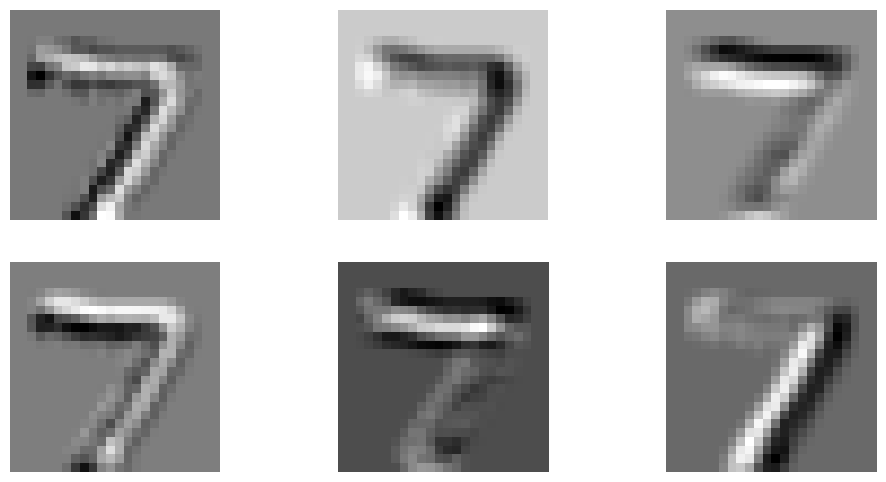

In [109]:
#Cartes de Caractéristiques
image,_ = test_dataset[0]

image = image.unsqueeze(0).to(device)

feature_maps = cnn_pad0.conv1(
    image
)

plt.figure(figsize=(12,6))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(
        feature_maps[0,i].detach().cpu(),
        cmap="gray"
    )

    plt.axis("off")

plt.show()

In [110]:
#Comparaison MLP vs CNN
class MLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(
            28*28,
            128
        )

        self.fc2 = nn.Linear(
            128,
            10
        )

    def forward(self,x):

        x = x.view(
            x.size(0),
            -1
        )

        x = torch.relu(
            self.fc1(x)
        )

        return self.fc2(x)